In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.drop(columns = ['RowNumber',	'CustomerId', 'Surname'], inplace = True)

In [5]:
df.head(1)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.0,1,1,1,101348.88,1


In [6]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [8]:
df = pd.get_dummies(df, columns = ['Geography','Gender'],drop_first = True)

In [9]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [10]:
X = df.drop(columns = ['Exited'])

In [11]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [12]:
y = df['Exited'].values

In [13]:
y

array([1, 0, 1, ..., 1, 1, 0])

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=0)

In [15]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
7389,667,34,5,0.00,2,1,0,163830.64,False,True,False
9275,427,42,1,75681.52,1,1,1,57098.00,True,False,True
2995,535,29,2,112367.34,1,1,0,185630.76,False,False,False
5316,654,40,5,105683.63,1,1,0,173617.09,False,True,True
356,850,57,8,126776.30,2,1,1,132298.49,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9225,594,32,4,120074.97,2,1,1,162961.79,True,False,False
4859,794,22,4,114440.24,1,1,1,107753.07,False,True,False
3264,738,35,5,161274.05,2,1,0,181429.87,False,False,True
9845,590,38,9,0.00,2,1,1,148750.16,False,True,False


In [16]:
y_train

array([0, 0, 0, ..., 0, 0, 1])

In [17]:
X_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9394,597,35,8,131101.04,1,1,1,192852.67,True,False,False
898,523,40,2,102967.41,1,1,0,128702.10,False,False,False
2398,706,42,8,95386.82,1,1,1,75732.25,False,True,False
5906,788,32,4,112079.58,1,0,0,89368.59,False,False,True
2343,706,38,5,163034.82,2,1,1,135662.17,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1037,625,24,1,0.00,2,1,1,180969.55,False,False,False
2899,586,35,7,0.00,2,1,0,70760.69,False,False,False
9549,578,36,1,157267.95,2,1,0,141533.19,False,True,True
2740,650,34,4,142393.11,1,1,1,11276.48,True,False,True


In [18]:
# pip install keras

In [19]:
# !pip install tensorflow

In [20]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [21]:
model = Sequential()

In [22]:
model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\Pratik\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='Adam',loss = 'binary_crossentropy', metrics = ['accuracy'])

In [25]:
history = model.fit(X_train,y_train,batch_size=50,epochs=50,verbose=1,validation_split=0.2)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2042 - loss: 1.1795 - val_accuracy: 0.2031 - val_loss: 0.8988
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4161 - loss: 0.7439 - val_accuracy: 0.7969 - val_loss: 0.6342
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7958 - loss: 0.5887 - val_accuracy: 0.7969 - val_loss: 0.5538
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7958 - loss: 0.5382 - val_accuracy: 0.7969 - val_loss: 0.5246
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7958 - loss: 0.5187 - val_accuracy: 0.7969 - val_loss: 0.5122
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7958 - loss: 0.5104 - val_accuracy: 0.7969 - val_loss: 0.5051
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7958 - loss: 0.5068 - val_accuracy: 0.7969 - val_loss: 0.5050
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7958 - loss: 0.5064 - val_accuracy: 0

In [26]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


In [27]:
y_pred

array([[0.23056866],
       [0.23056866],
       [0.24697834],
       ...,
       [0.24697834],
       [0.23977073],
       [0.23056866]], dtype=float32)

In [28]:
y_pred = y_pred.argmax(axis=-1)

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7975

In [30]:
model.get_weights()[0]

array([[ 0.12789944,  0.35233837,  0.5706467 ,  0.01482964,  0.24587941,
         0.00391173,  0.3323979 ,  0.2470544 , -0.45313048,  0.59252685,
        -0.27736783],
       [ 0.34924236,  0.6002073 ,  0.14352834, -0.09451967, -0.2600818 ,
         0.2671603 ,  0.42177996, -0.39072818, -0.43269467,  0.08482837,
         0.26265034],
       [-0.26514655,  0.39236176,  0.30885786, -0.41196874,  0.27868795,
        -0.5078605 ,  0.4245182 , -0.35107395,  0.54308933,  0.10131142,
        -0.26536998],
       [ 0.06944884, -0.12071958, -0.2657359 ,  0.29831064,  0.10706246,
        -0.5130271 ,  0.36821675,  0.15860729, -0.28477255,  0.00709179,
        -0.46708077],
       [ 0.08826651, -0.21683863, -0.30526355,  0.07761818,  0.28382713,
        -0.06711364,  0.2387698 , -0.5723734 ,  0.18278962, -0.2770579 ,
         0.2209372 ],
       [-0.28823927,  0.23825295,  0.11585551, -0.05614519, -0.20330274,
         0.05282837, -0.32014164, -0.22977069,  0.03883918, -0.2302771 ,
         0.383

In [31]:
len(model.get_weights()[0])

11

In [32]:
model.get_weights()[1]

array([ 1.1684497e-01,  5.8316287e-02,  3.4191370e-02,  0.0000000e+00,
        0.0000000e+00, -1.1200201e-27,  3.2984182e-02, -4.6685219e-02,
        4.2345829e-02,  7.2977155e-02, -3.7623846e-04], dtype=float32)

In [33]:
layer1 = model.layers[0]

In [42]:
w1 , b1 = layer1.get_weights()

In [43]:
w1

array([[ 0.12789944,  0.35233837,  0.5706467 ,  0.01482964,  0.24587941,
         0.00391173,  0.3323979 ,  0.2470544 , -0.45313048,  0.59252685,
        -0.27736783],
       [ 0.34924236,  0.6002073 ,  0.14352834, -0.09451967, -0.2600818 ,
         0.2671603 ,  0.42177996, -0.39072818, -0.43269467,  0.08482837,
         0.26265034],
       [-0.26514655,  0.39236176,  0.30885786, -0.41196874,  0.27868795,
        -0.5078605 ,  0.4245182 , -0.35107395,  0.54308933,  0.10131142,
        -0.26536998],
       [ 0.06944884, -0.12071958, -0.2657359 ,  0.29831064,  0.10706246,
        -0.5130271 ,  0.36821675,  0.15860729, -0.28477255,  0.00709179,
        -0.46708077],
       [ 0.08826651, -0.21683863, -0.30526355,  0.07761818,  0.28382713,
        -0.06711364,  0.2387698 , -0.5723734 ,  0.18278962, -0.2770579 ,
         0.2209372 ],
       [-0.28823927,  0.23825295,  0.11585551, -0.05614519, -0.20330274,
         0.05282837, -0.32014164, -0.22977069,  0.03883918, -0.2302771 ,
         0.383

In [44]:
b1

array([ 1.1684497e-01,  5.8316287e-02,  3.4191370e-02,  0.0000000e+00,
        0.0000000e+00, -1.1200201e-27,  3.2984182e-02, -4.6685219e-02,
        4.2345829e-02,  7.2977155e-02, -3.7623846e-04], dtype=float32)

In [37]:
layer2 = model.layers[1]

In [38]:
w2 , b2 = layer1.get_weights()

In [39]:
w2

array([[ 0.12789944,  0.35233837,  0.5706467 ,  0.01482964,  0.24587941,
         0.00391173,  0.3323979 ,  0.2470544 , -0.45313048,  0.59252685,
        -0.27736783],
       [ 0.34924236,  0.6002073 ,  0.14352834, -0.09451967, -0.2600818 ,
         0.2671603 ,  0.42177996, -0.39072818, -0.43269467,  0.08482837,
         0.26265034],
       [-0.26514655,  0.39236176,  0.30885786, -0.41196874,  0.27868795,
        -0.5078605 ,  0.4245182 , -0.35107395,  0.54308933,  0.10131142,
        -0.26536998],
       [ 0.06944884, -0.12071958, -0.2657359 ,  0.29831064,  0.10706246,
        -0.5130271 ,  0.36821675,  0.15860729, -0.28477255,  0.00709179,
        -0.46708077],
       [ 0.08826651, -0.21683863, -0.30526355,  0.07761818,  0.28382713,
        -0.06711364,  0.2387698 , -0.5723734 ,  0.18278962, -0.2770579 ,
         0.2209372 ],
       [-0.28823927,  0.23825295,  0.11585551, -0.05614519, -0.20330274,
         0.05282837, -0.32014164, -0.22977069,  0.03883918, -0.2302771 ,
         0.383

In [40]:
b2

array([ 1.1684497e-01,  5.8316287e-02,  3.4191370e-02,  0.0000000e+00,
        0.0000000e+00, -1.1200201e-27,  3.2984182e-02, -4.6685219e-02,
        4.2345829e-02,  7.2977155e-02, -3.7623846e-04], dtype=float32)

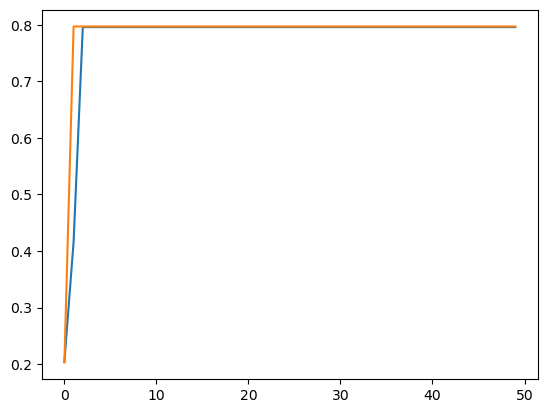

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy']) 